## Importing Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import glob
import sys
from dotenv import load_dotenv
import regex as re

import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import NumericType, StringType, BooleanType
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Tokenizer,
    StopWordsRemover,
    HashingTF,
    IDF,
    VectorAssembler,
    StandardScaler,
    StringIndexer
)
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import StringType
from pyspark.storagelevel import StorageLevel

import nltk
from nltk.stem import PorterStemmer

nltk.download('punkt', quiet = True)

True

In [3]:
# Hardcoding since working with venv
load_dotenv()

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
os.environ['PATH'] = os.environ.get('HADOOP_HOME', '') + r'\bin;' + os.environ.get('PATH', '')

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"HADOOP_HOME: {os.environ.get('HADOOP_HOME')}")
print(f"PYSPARK_PYTHON: {os.environ.get('PYSPARK_PYTHON')}")
print(f"PYSPARK_DRIVER_PYTHON: {os.environ.get('PYSPARK_DRIVER_PYTHON')}")
print(f"PATH: {os.environ.get('PATH')}")

JAVA_HOME: C:\Users\sento\AppData\Local\Programs\Eclipse Adoptium\jdk-11.0.31.11-hotspot
HADOOP_HOME: C:\hadoop
PYSPARK_PYTHON: c:\Users\sento\AppData\Local\Programs\Python\Python311\python.exe
PYSPARK_DRIVER_PYTHON: c:\Users\sento\AppData\Local\Programs\Python\Python311\python.exe
PATH: C:\hadoop\bin;c:\Users\sento\AppData\Local\Programs\Python\Python311;c:\Users\sento\AppData\Roaming\Python\Python311\Scripts;C:\Users\sento\AppData\Local\Programs\Python\Python311;C:\Users\sento\AppData\Local\Programs\Python\Python311\Scripts;C:\Program Files\Git\cmd;C:\Program Files\Docker\Docker\resources\bin;C:\Program Files\NVIDIA Corporation\NVIDIA App\NvDLISR;C:\Users\sento\AppData\Local\Programs\Eclipse Adoptium\jdk-11.0.31.11-hotspot\bin;C:\hadoop\bin;C:\spark\spark-3.5.8-bin-hadoop3\bin;C:\Users\sento\AppData\Local\Programs\Eclipse Adoptium\jdk-11.0.31.11-hotspot\bin;C:\Users\sento\AppData\Local\Programs\Python\Python311\Scripts\;C:\Users\sento\AppData\Local\Programs\Python\Python311\;C:\Users

## Loading Spark Context

In [4]:
spark = SparkSession.builder \
    .appName("SEEP") \
    .master("local[4]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.memory.fraction", "0.8") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.maxResultSize", "3g") \
    .config("spark.sql.execution.arrow.maxRecordsPerBatch", "5000") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

sc = spark.sparkContext

print(f"Spark version: {spark.version}")
print(f"App name: {sc.appName}")
print(f"Master: {sc.master}")

Spark version: 3.5.8
App name: SEEP
Master: local[4]


In [4]:
spark.stop()

## Loading Dataset

### For Reviews

In [10]:
pattern_reviews = r'../data/reviews/reviews/steam_reviews_*' #1

files_reviews = glob.glob(pattern_reviews)
files_reviews[:5]

['../data/reviews/reviews\\steam_reviews_2025-08-22_0.parquet',
 '../data/reviews/reviews\\steam_reviews_2025-08-22_1.parquet',
 '../data/reviews/reviews\\steam_reviews_2025-08-22_10.parquet',
 '../data/reviews/reviews\\steam_reviews_2025-08-22_100.parquet',
 '../data/reviews/reviews\\steam_reviews_2025-08-22_101.parquet']

In [5]:
# check if all parquet in reviews
all_file_types_review = set()
for file in files_reviews:
    all_file_types_review.add(file.split('.')[-1])

all_file_types_review

{'parquet'}

In [11]:
df_reviews = spark.read.parquet(*files_reviews) # 2
df_reviews.printSchema()

root
 |-- rec_id: long (nullable = true)
 |-- author_id: long (nullable = true)
 |-- appid: long (nullable = true)
 |-- playtime_forever: long (nullable = true)
 |-- playtime_last_two_weeks: long (nullable = true)
 |-- playtime_at_review: long (nullable = true)
 |-- num_games_owned: long (nullable = true)
 |-- num_reviews: long (nullable = true)
 |-- last_played: long (nullable = true)
 |-- language: string (nullable = true)
 |-- review: string (nullable = true)
 |-- timestamp_created: long (nullable = true)
 |-- timestamp_updated: long (nullable = true)
 |-- voted_up: boolean (nullable = true)
 |-- votes_up: long (nullable = true)
 |-- votes_funny: long (nullable = true)
 |-- weighted_vote_score: double (nullable = true)
 |-- comment_count: long (nullable = true)
 |-- steam_purchase: boolean (nullable = true)
 |-- received_for_free: boolean (nullable = true)
 |-- written_during_early_access: boolean (nullable = true)
 |-- primarily_steam_deck: boolean (nullable = true)
 |-- scrape_dat

In [7]:
df_reviews.show(5)

+---------+-----------------+-------+----------------+-----------------------+------------------+---------------+-----------+-----------+--------+--------------------+-----------------+-----------------+--------+--------+-----------+-------------------+-------------+--------------+-----------------+---------------------------+--------------------+-----------+
|   rec_id|        author_id|  appid|playtime_forever|playtime_last_two_weeks|playtime_at_review|num_games_owned|num_reviews|last_played|language|              review|timestamp_created|timestamp_updated|voted_up|votes_up|votes_funny|weighted_vote_score|comment_count|steam_purchase|received_for_free|written_during_early_access|primarily_steam_deck|scrape_date|
+---------+-----------------+-------+----------------+-----------------------+------------------+---------------+-----------+-----------+--------+--------------------+-----------------+-----------------+--------+--------+-----------+-------------------+-------------+---------

### For Games

In [12]:
pattern_games = r'../data/games/games/steam_games_*' #3 

files_games = glob.glob(pattern_games)
files_games[:5]

['../data/games/games\\steam_games_2025-08-12_0.parquet',
 '../data/games/games\\steam_games_2025-08-12_1.parquet',
 '../data/games/games\\steam_games_2025-08-12_10.parquet',
 '../data/games/games\\steam_games_2025-08-12_11.parquet',
 '../data/games/games\\steam_games_2025-08-12_12.parquet']

In [9]:
# check if all parquet in games
all_file_types_games = set()
for file in files_games:
    all_file_types_games.add(file.split('.')[-1])

all_file_types_games

{'parquet'}

In [13]:
df_games = spark.read.parquet(*files_games) # 4
df_games.printSchema()

root
 |-- appid: long (nullable = true)
 |-- name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- required_age: long (nullable = true)
 |-- is_free: boolean (nullable = true)
 |-- minimum_pc_requirements: string (nullable = true)
 |-- recommended_pc_requirements: string (nullable = true)
 |-- controller_support: string (nullable = true)
 |-- detailed_description: string (nullable = true)
 |-- about_the_game: string (nullable = true)
 |-- short_description: string (nullable = true)
 |-- supported_languages: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- header_image: string (nullable = true)
 |-- developers: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- publishers: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: double (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- genres: array (nullable = true)
 |    |-- el

In [11]:
df_games.show(5)

+-------+--------------------+----+------------+-------+-----------------------+---------------------------+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------+--------------------+--------------------+---------------+-----------+-------------+------------+-----------+---------------+---+------------+--------------------+-----------+
|  appid|                name|type|required_age|is_free|minimum_pc_requirements|recommended_pc_requirements|controller_support|detailed_description|      about_the_game|   short_description| supported_languages|        header_image|          developers|          publishers| price|          categories|              genres|windows_support|mac_support|linux_support|release_date|coming_soon|recommendations|dlc|review_score|   review_score_desc|scrape_date|
+-------+--------------------+----+------------+-------+-----------------------+------

### Others

In [8]:
df_games_id = spark.read.parquet('../data/games/games/steam_ids.parquet') # 5
df_games_id.show()

+-------+---------------------------+
|  appid|                       name|
+-------+---------------------------+
|3058980|       Veilcrest: Trial ...|
| 857060|                CCCP CALLS!|
| 477270|              Lightblade VR|
| 626522|       Fate/EXTELLA - Or...|
|1310390|           Mine Trap Reborn|
| 852370|       Fantasy Grounds -...|
|2143600|             Axom: Conquest|
|2490800|閃攻機人アスラ - ASURA T...|
|3772830|       Haunted Room : 20...|
|2512560|            Butcher's Creek|
|1700505|       Tiger Fighter 193...|
|2497080|              Roody:2d Demo|
| 791670|       Chess of Blades -...|
|2674800|       CUSTOM ORDER MAID...|
|2420300|                Rap Attack!|
|1822510|               Fog & Silver|
| 669630|                   Hollowed|
|1492370|            Retis Tormentum|
|3107930|       Memology 2: old t...|
|2267180|       The Ranch of Rive...|
+-------+---------------------------+
only showing top 20 rows



## EDA

In [14]:
# copy df
df_reviews_copy = df_reviews.alias('df_reviews_copy') # 6
df_games_copy = df_games.alias('df_games_copy')

In [10]:
# Count no. of records
print(f"No. of records in Reviews: {df_reviews_copy.count()}")
print(f"No. of records in Games: {df_games_copy.count()}")

No. of records in Reviews: 91013016
No. of records in Games: 196310


In [15]:
# No. of duplicated review ids
df_reviews_copy.select("rec_id").distinct().count()

90913741

In [49]:
# No. of duplicated game ids
df_games_copy.select("appid").distinct().count()

196310

In [50]:
# Checking for null values in reviews
for col in df_reviews_copy.columns:
    null_count = df_reviews_copy.filter(F.col(col).isNull()).count()
    print(f"{col}: {null_count}")

rec_id: 0
author_id: 0
appid: 0
playtime_forever: 53979
playtime_last_two_weeks: 83035153
playtime_at_review: 119223
num_games_owned: 45257560
num_reviews: 0
last_played: 53979
language: 0
review: 0
timestamp_created: 0
timestamp_updated: 0
voted_up: 0
votes_up: 0
votes_funny: 0
weighted_vote_score: 0
comment_count: 0
steam_purchase: 0
received_for_free: 0
written_during_early_access: 0
primarily_steam_deck: 0
scrape_date: 0


In [51]:
# Checking for null values in games
for col in df_games_copy.columns:
    null_count = df_games_copy.filter(F.col(col).isNull()).count()
    print(f"{col}: {null_count}")

appid: 0
name: 0
type: 0
required_age: 1
is_free: 0
minimum_pc_requirements: 27
recommended_pc_requirements: 68552
controller_support: 144049
detailed_description: 0
about_the_game: 0
short_description: 0
supported_languages: 0
header_image: 0
developers: 0
publishers: 0
price: 65825
categories: 0
genres: 0
windows_support: 0
mac_support: 0
linux_support: 0
release_date: 0
coming_soon: 0
recommendations: 174184
dlc: 0
review_score: 11
review_score_desc: 11
scrape_date: 0


In [54]:
## Summary Stats of numerical cols

review_numeric_cols = [
    field.name for field in df_reviews_copy.schema.fields 
    if isinstance(field.dataType, NumericType)
]

game_numeric_cols = [
    field.name for field in df_games_copy.schema.fields 
    if isinstance(field.dataType, NumericType)
]

print("Review numeric columns:")
print(review_numeric_cols)

print("Game numeric columns:")
print(game_numeric_cols)

df_reviews_copy.select(review_numeric_cols).describe().show(truncate=False)
df_games_copy.select(game_numeric_cols).describe().show(truncate=False)

Review numeric columns:
['rec_id', 'author_id', 'appid', 'playtime_forever', 'playtime_last_two_weeks', 'playtime_at_review', 'num_games_owned', 'num_reviews', 'last_played', 'timestamp_created', 'timestamp_updated', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count']
Game numeric columns:
['appid', 'required_age', 'price', 'recommendations', 'review_score']
+-------+--------------------+---------------------+-----------------+------------------+-----------------------+------------------+-----------------+------------------+--------------------+-------------------+--------------------+------------------+--------------------+---------------------+-------------------+
|summary|rec_id              |author_id            |appid            |playtime_forever  |playtime_last_two_weeks|playtime_at_review|num_games_owned  |num_reviews       |last_played         |timestamp_created  |timestamp_updated   |votes_up          |votes_funny         |weighted_vote_score  |comment_count    

In [ ]:
# Summary stats of categorical cols

review_categorical_cols = [
    field.name for field in df_reviews_copy.schema.fields
    if isinstance(field.dataType, StringType) or isinstance(field.dataType, BooleanType)
]

game_categorical_cols = [
    field.name for field in df_games_copy.schema.fields
    if isinstance(field.dataType, StringType) or isinstance(field.dataType, BooleanType)
]

print("Review categorical columns:")
print(review_categorical_cols)

print("Game categorical columns:")
print(game_categorical_cols)

for c in review_categorical_cols:
    print(f"\nTop values for reviews column: {c}")
    df_reviews_copy.groupBy(c).count().orderBy(F.desc("count")).show(10, truncate=False)

for c in game_categorical_cols:
    print(f"\nTop values for games column: {c}")
    df_games_copy.groupBy(c).count().orderBy(F.desc("count")).show(10, truncate=False)

Review categorical columns:
['language', 'review', 'voted_up', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'primarily_steam_deck']
Game categorical columns:
['name', 'type', 'is_free', 'minimum_pc_requirements', 'recommended_pc_requirements', 'controller_support', 'detailed_description', 'about_the_game', 'short_description', 'header_image', 'windows_support', 'mac_support', 'linux_support', 'release_date', 'coming_soon', 'review_score_desc']

Top values for reviews column: language
+---------+--------+
|language |count   |
+---------+--------+
|english  |41997227|
|schinese |16178063|
|russian  |8992635 |
|brazilian|3757096 |
|spanish  |3553091 |
|german   |2784612 |
|turkish  |2514596 |
|koreana  |2010751 |
|french   |1890236 |
|polish   |1655454 |
+---------+--------+
only showing top 10 rows


Top values for reviews column: review


In [16]:
# Review dist per game (appid)

df_reviews_copy.groupBy("appid") \
    .agg(
        F.count("*").alias("review_count"),
        F.countDistinct("author_id").alias("unique_reviewers"),
        F.avg("playtime_forever").alias("avg_playtime_forever")
    ) \
    .orderBy(F.desc("review_count")).show(20, truncate = False)

+-------+------------+----------------+--------------------+
|appid  |review_count|unique_reviewers|avg_playtime_forever|
+-------+------------+----------------+--------------------+
|578080 |1746069     |1746068         |54085.83866321357   |
|105600 |1141224     |1141216         |21815.772902683093  |
|252490 |1040475     |1040455         |64160.59767375254   |
|2358720|852419      |852419          |4711.792745117132   |
|431960 |849357      |849356          |13489.014709968495  |
|413150 |787008      |787005          |13068.700372804342  |
|1245620|782719      |782709          |14666.916943373037  |
|553850 |756352      |756352          |10725.480608235319  |
|292030 |731786      |731786          |9722.811562139153   |
|4000   |722576      |722574          |30764.48875689201   |
|1174180|708886      |708883          |10752.059909491794  |
|1086940|685666      |685666          |16184.17943138496   |
|227300 |674068      |674066          |16094.337108422296  |
|739630 |637337      |63

In [12]:
# app type distribution

df_games_copy.groupBy("type") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(truncate=False)

+-----------+------+
|type       |count |
+-----------+------+
|game       |139598|
|dlc        |47635 |
|demo       |7614  |
|music      |655   |
|video      |491   |
|advertising|141   |
|mod        |123   |
|series     |53    |
+-----------+------+



In [13]:
# Free v Paid dist

df_games_copy.groupBy("is_free") \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

+-------+------+
|is_free| count|
+-------+------+
|  false|165804|
|   true| 30506|
+-------+------+



In [14]:
# Min age required dist

df_games_copy.groupBy("required_age") \
    .count() \
    .orderBy(F.asc("required_age")) \
    .show(50)

+------------+------+
|required_age| count|
+------------+------+
|        NULL|     1|
|           0|192609|
|           1|     5|
|           3|     7|
|           5|     1|
|           6|     4|
|           7|    10|
|           8|     2|
|          10|    49|
|          11|     2|
|          12|    44|
|          13|   482|
|          14|     6|
|          15|     8|
|          16|    76|
|          17|  2536|
|          18|   464|
|          20|     1|
|          21|     2|
|         120|     1|
+------------+------+



In [15]:
# Playtime distribution
df_reviews_copy.select(
    F.min("playtime_forever").alias("min_playtime"),
    F.max("playtime_forever").alias("max_playtime"),
    F.avg("playtime_forever").alias("avg_playtime")
).show()

df_reviews_copy.select("playtime_forever").describe().show()

+------------+------------+------------------+
|min_playtime|max_playtime|      avg_playtime|
+------------+------------+------------------+
|           1|     6683538|11288.547634480783|
+------------+------------+------------------+

+-------+------------------+
|summary|  playtime_forever|
+-------+------------------+
|  count|          90959037|
|   mean|11288.547634480783|
| stddev| 37915.80015860064|
|    min|                 1|
|    max|           6683538|
+-------+------------------+



In [16]:
# Bucketing playtime

df_reviews_buckets = df_reviews_copy.withColumn(
    "playtime_bucket",
    F.when(F.col("playtime_forever") == 0, "0 hours")
    .when(F.col("playtime_forever") <= 60, "1 hour or less")
    .when(F.col("playtime_forever") <= 600, "1 to 10 hours")
    .when(F.col("playtime_forever") <= 3000, "10 to 50 hours")
    .when(F.col("playtime_forever") <= 6000, "50 to 100 hours")
    .otherwise("100+ hours")
)

df_reviews_buckets.groupBy("playtime_bucket") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(truncate=False)

+---------------+--------+
|playtime_bucket|count   |
+---------------+--------+
|10 to 50 hours |30545920|
|100+ hours     |26910370|
|1 to 10 hours  |17417052|
|50 to 100 hours|13103611|
|1 hour or less |3036063 |
+---------------+--------+



In [10]:
# Merge reviews and games
df_merged = df_reviews_copy.join(
    df_games,
    on="appid",
    how="left"
)

df_merged.show(5, truncate=False)

print(f"Merged rows: {df_merged.count():,}")

+------+---------+-----------------+----------------+-----------------------+------------------+---------------+-----------+-----------+--------+-----------------------------------------------------------------------------------------+-----------------+-----------------+--------+--------+-----------+-------------------+-------------+--------------+-----------------+---------------------------+--------------------+-----------+---------------+----+------------+-------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------+------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [18]:
# Reviews without matching game

unmatched_reviews = df_merged.filter(F.col("name").isNull()).count()

print(f"Reviews without matching game info: {unmatched_reviews:,}")
print(f"Percentage unmatched: {(unmatched_reviews / df_reviews_copy.count()) * 100:.2f}%")

Reviews without matching game info: 0
Percentage unmatched: 0.00%


In [17]:
# Top Reviewed games

top_games = df_merged.groupBy("appid", "name") \
    .agg(
        F.count("*").alias("review_count"),
        F.countDistinct("author_id").alias("unique_reviewers"),
        F.round(F.avg("playtime_forever"), 2).alias("avg_playtime_forever")
    ) \
    .orderBy(F.desc("review_count"))

top_games.show(20, truncate=False)

+-------+-------------------------+------------+----------------+--------------------+
|appid  |name                     |review_count|unique_reviewers|avg_playtime_forever|
+-------+-------------------------+------------+----------------+--------------------+
|578080 |PUBG: BATTLEGROUNDS      |1746069     |1746068         |54085.84            |
|105600 |Terraria                 |1141224     |1141216         |21815.77            |
|252490 |Rust                     |1040475     |1040455         |64160.6             |
|2358720|Black Myth: Wukong       |852419      |852419          |4711.79             |
|431960 |Wallpaper Engine         |849357      |849356          |13489.01            |
|413150 |Stardew Valley           |787008      |787005          |13068.7             |
|1245620|ELDEN RING               |782719      |782709          |14666.92            |
|553850 |HELLDIVERS™ 2            |756352      |756352          |10725.48            |
|292030 |The Witcher 3: Wild Hunt |731786  

In [22]:
# Average Weight Vote Score per recieve type

df_merged.groupBy('received_for_free').agg(F.avg("weighted_vote_score").alias('Average Weight Vote Score'),
                                            F.count("received_for_free").alias('Count')).show(5)

+-----------------+-------------------------+--------+
|received_for_free|Average Weight Vote Score|   Count|
+-----------------+-------------------------+--------+
|             true|       0.5028716756505985| 1395896|
|            false|       0.5074299808803107|89612490|
+-----------------+-------------------------+--------+



In [23]:
# No of reviews voted up
df_merged.groupBy('voted_up').count().show()

+--------+--------+
|voted_up|   count|
+--------+--------+
|    true|79438572|
|   false|11569814|
+--------+--------+



In [24]:
# No of reviews by language (English is the primary mode of reviews based on count)
df_merged.groupBy('language').agg(F.sum('num_reviews').alias('No of Reviews')).sort('No of Reviews', ascending = False).show()

+----------+-------------+
|  language|No of Reviews|
+----------+-------------+
|   english|   1223424080|
|   russian|    344392424|
|  schinese|    318481431|
|   turkish|    111486943|
|    german|     79343813|
| brazilian|     78824174|
|   koreana|     70569692|
|   spanish|     67218097|
|    french|     43806093|
|  tchinese|     33547668|
|    polish|     31649314|
|  japanese|     21875400|
|     latam|     21763948|
|   italian|     12498565|
|     czech|     11345910|
| ukrainian|     10020213|
|      thai|      5275000|
|portuguese|      3583968|
|  romanian|      3478277|
|   swedish|      3353345|
+----------+-------------+
only showing top 20 rows



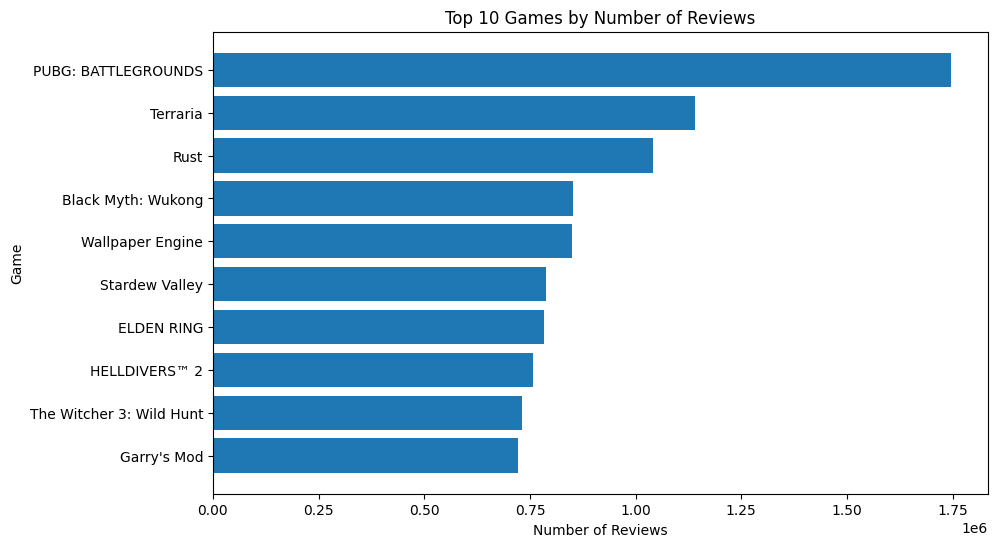

In [18]:
# Visualized top 10 games

top_games_pd = top_games.limit(10).toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_games_pd["name"], top_games_pd["review_count"])
plt.xlabel("Number of Reviews")
plt.ylabel("Game")
plt.title("Top 10 Games by Number of Reviews")
plt.gca().invert_yaxis()
plt.show()

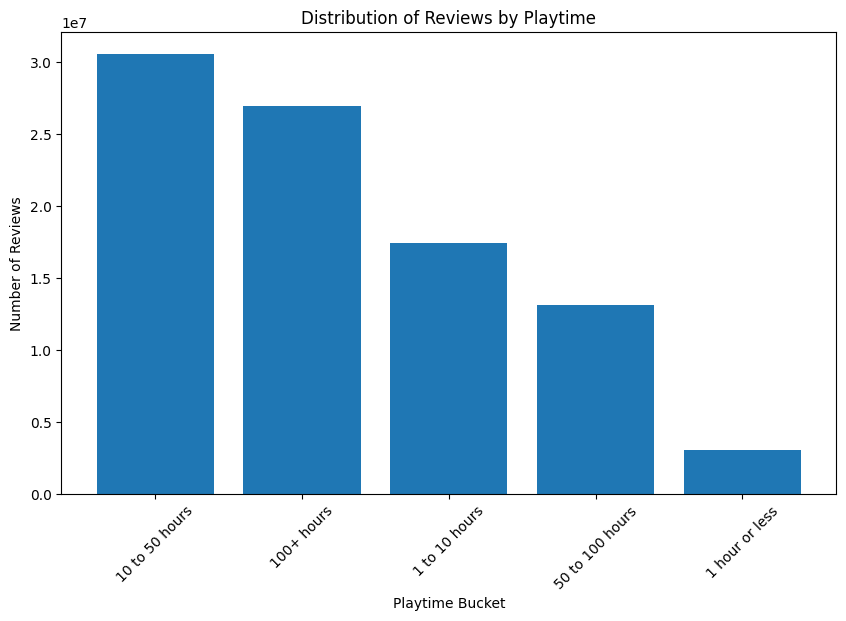

In [ ]:
# Visualize playtime buckets

playtime_bucket_pd = df_reviews_buckets.groupBy("playtime_bucket") \
    .count() \
    .orderBy(F.desc("count")) \
    .toPandas()

plt.figure(figsize=(10, 6))
plt.bar(playtime_bucket_pd["playtime_bucket"], playtime_bucket_pd["count"])
plt.xlabel("Playtime Bucket")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Reviews by Playtime")
plt.xticks(rotation=45)
plt.show()

## Data Preprocessing

In [13]:
df_reviews_copy.show(5)

+---------+-----------------+-------+----------------+-----------------------+------------------+---------------+-----------+-----------+--------+--------------------+-----------------+-----------------+--------+--------+-----------+-------------------+-------------+--------------+-----------------+---------------------------+--------------------+-----------+
|   rec_id|        author_id|  appid|playtime_forever|playtime_last_two_weeks|playtime_at_review|num_games_owned|num_reviews|last_played|language|              review|timestamp_created|timestamp_updated|voted_up|votes_up|votes_funny|weighted_vote_score|comment_count|steam_purchase|received_for_free|written_during_early_access|primarily_steam_deck|scrape_date|
+---------+-----------------+-------+----------------+-----------------------+------------------+---------------+-----------+-----------+--------+--------------------+-----------------+-----------------+--------+--------+-----------+-------------------+-------------+---------

In [15]:
# Get only english reviews #run here

df_reviews_english = df_reviews_copy.filter(F.lower(F.col('language')) == 'english')
df_reviews_english.show(5)

print(f"No. of records before filtering: {df_reviews_copy.count()}")
print(f"No. of records after filtering: {df_reviews_english.count()}")

+---------+-----------------+-------+----------------+-----------------------+------------------+---------------+-----------+-----------+--------+--------------------+-----------------+-----------------+--------+--------+-----------+-------------------+-------------+--------------+-----------------+---------------------------+--------------------+-----------+
|   rec_id|        author_id|  appid|playtime_forever|playtime_last_two_weeks|playtime_at_review|num_games_owned|num_reviews|last_played|language|              review|timestamp_created|timestamp_updated|voted_up|votes_up|votes_funny|weighted_vote_score|comment_count|steam_purchase|received_for_free|written_during_early_access|primarily_steam_deck|scrape_date|
+---------+-----------------+-------+----------------+-----------------------+------------------+---------------+-----------+-----------+--------+--------------------+-----------------+-----------------+--------+--------+-----------+-------------------+-------------+---------

In [16]:
df_for_training = df_reviews_english.select(['rec_id', #Run here
                                          'appid', 
                                          'playtime_at_review', 
                                          'review', 
                                          'voted_up',
                                          'received_for_free',
                                          'written_during_early_access',
                                          'num_reviews',
                                          'language']).join(df_games_copy.select(['appid', 'price']), 'appid', 'left')

print("Reviews columns before:", len(df_reviews_copy.columns))
print("Total training columns after:", len(df_for_training.columns))

Reviews columns before: 23
Total training columns after: 10


In [ ]:
# Removing duplicates (Scrap muna since antagal nya magchache * fix = lahat andito sa iisang big)

df_reviews_cleaner = df_for_training.dropDuplicates(['rec_id'])

print("Training rows before:", df_reviews_english.count())
print("Training rows after:", df_reviews_cleaner.count())

df_reviews_cleaner.limit(5).select('review').show(truncate = False)

Reviews rows before: 41997227


## Text Preprocessing

### Text Cleaning and Stemming

In [11]:
stemmer = PorterStemmer() # 10

@pandas_udf(StringType())
def vectorized_clean_and_stem_fast(reviews: pd.Series) -> pd.Series:
    stemmer = PorterStemmer()
    
    def process_text(text):
        if text is None or text.strip() == "":
            return ""
        text = re.sub(r'[\n\t\r]', ' ', text) # whitespaces
        text = re.sub(r'<[^>]+>', '', text) # HTML
        text = re.sub(r'[^a-zA-Z\s]', '', text) # spcial chars
        text = text.lower().strip()
        text = re.sub(r'(.)\1{2,}', r'\1\1', text) # Squash elongated words
        text = text[:10_000] # truncate safety net
        
        tokens = text.split()
        stemmed = []
        for token in tokens:
            try:
                if len(token) > 50:
                    stemmed.append(token)
                else:
                    stemmed.append(stemmer.stem(token))
            except RecursionError:
                stemmed.append(token)
                
        return " ".join(stemmed)
    
    return reviews.astype(str).apply(process_text)

In [ ]:
# 3. Add the UDF and stream straight to parquet
df_stemmed = df_for_training.withColumn('stemmed_review', vectorized_clean_and_stem_fast('review'))
df_stemmed.write.parquet("df_stemmed.parquet", mode="overwrite")

In [6]:
pattern = r'../data/experiments/experiments/df_stemmed.parquet/*.parquet' # Run here

files = glob.glob(pattern)

df_stemmed = spark.read.parquet(*files)
df_stemmed.show()
df_stemmed.count()

+--------------------+--------------------+
|              review|      stemmed_review|
+--------------------+--------------------+
|I have played thi...|i have play thi g...|
|Great design,game...|great designgamep...|
|The games now ful...|the game now full...|
|Rondo's map reall...|rondo map realli ...|
|would recommend 1...|would recommend m...|
|for the LOVE OF G...|for the love of g...|
|           cringe xd|            cring xd|
|When i first star...|when i first star...|
|                 yum|                 yum|
|nmsl nmsl nmsl nm...|nmsl nmsl nmsl nm...|
| Most realistic M...|most realist mili...|
|TOO MANY CHEATERS...|too mani cheater ...|
|Pros:\n- Fun game...|pro fun gameplay ...|
|ничего лучше не с...|                    |
|Amazingly addicti...|amazingli addict ...|
|While the premise...|while the premis ...|
|great made battle...|great made battl ...|
|need to fix this ...|need to fix thi h...|
|377 hours ago: Ha...|hour ago hacker s...|
|               Pans.|          

41997227

In [17]:
df_combined = df_for_training.join(df_stemmed, 'review')
df_combined.show(5, truncate = False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [19]:
df_combined_encoded = df_combined.withColumn(
    "received_for_free_encoded",
    F.col("received_for_free").cast("int")
).withColumn(
    "written_during_early_access_encoded",
    F.col("written_during_early_access").cast("int")
)

df_combined_encoded.show(5, truncate = False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Tokenizer and Stopwords Removal

In [ ]:
tokenizer = Tokenizer(
    inputCol = "stemmed_review",
    outputCol = "tokens"
)

stop_words_remover = StopWordsRemover(
    inputCol = "tokens",
    outputCol = "filtered_tokens"
)

### TF-IDF

In [34]:
vocab_size = 10_000 # Seb note: change ts

tf = HashingTF(
    inputCol = "filtered_tokens",
    outputCol = "raw_tf",
    numFeatures = vocab_size
)

idf = IDF(
    inputCol = "raw_tf",
    outputCol = "tfidf_features"
)

### Scalers

In [ ]:
additional_assembler = VectorAssembler(
    inputCols = [],  # Seb note: Add dito columns na ilalagay
    outputCol = "additional_raw"
)

scaler = StandardScaler(
    inputCol = "additional_raw",
    outputCol = "additional_features",
    withMean = False,
    withStd = True
)

### Combine features into one

In [ ]:
final_assembler = VectorAssembler(
    inputCols = ["tfidf_features", "additional_features"],
    outputCol = "final_features"
)


### Encoding the label

In [ ]:
label_indexer = StringIndexer(
    inputCol="voted_up",
    outputCol="label_index"
)

## Model Training using Multinomial NaiveBayes

In [ ]:
nb = NaiveBayes(
    featuresCol="final_features",
    labelCol="label_index",
    modelType="multinomial",
    smoothing=1.0  # Laplace smoothing5
)

In [ ]:
pipeline = Pipeline(stages=[
    tokenizer,
    stop_words_remover,
    tf,
    idf,
    additional_assembler,
    scaler,
    final_assembler,
    label_indexer,
    nb
])

### Train Test split

In [52]:
train_df, test_df = df_stemmed.randomSplit([0.8, 0.2], seed = 67)
train_df.show()

+------+------------+--------------+
|review|clean_review|stemmed_review|
+------+------------+--------------+
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
+------+------------+--------------+
only showing top 20 rows



In [48]:
test_df.show()

+------+------------+--------------+
|review|clean_review|stemmed_review|
+------+------------+--------------+
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
|      |            |              |
+------+------------+--------------+
only showing top 20 rows



In [ ]:
train_df, test_df = df_combined_encoded.randomSplit([0.8, 0.2], seed = 67)

model = pipeline.fit(train_df)
y_pred = pipeline.transform(test_df)

+------+----------+------------+------------+--------------+------+---------------+--------------------+-----------------------------------+
|review|clean_text|stemmed_text|clean_review|stemmed_review|tokens|filtered_tokens|raw_tf              |tfidf_features                     |
+------+----------+------------+------------+--------------+------+---------------+--------------------+-----------------------------------+
|      |          |            |            |              |[]    |[]             |(10000,[3372],[1.0])|(10000,[3372],[1.1355438660535349])|
|      |          |            |            |              |[]    |[]             |(10000,[3372],[1.0])|(10000,[3372],[1.1355438660535349])|
|      |          |            |            |              |[]    |[]             |(10000,[3372],[1.0])|(10000,[3372],[1.1355438660535349])|
|      |          |            |            |              |[]    |[]             |(10000,[3372],[1.0])|(10000,[3372],[1.1355438660535349])|
|      |     

## Model Evaluation

In [ ]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="voted_up",
    predictionCol="prediction"
)

accuracy = evaluator.evaluate(y_pred, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(y_pred, {evaluator.metricName: "f1"})
precision = evaluator.evaluate(y_pred, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(y_pred, {evaluator.metricName: "weightedRecall"})

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")